In [1]:
import pandas as pd
import numpy as np 
import re
import gradio as gr
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import dataset from kaggle
import kagglehub 

path = kagglehub.dataset_download("tusharkute/maharashtra-heritage-forts")

print("Path to dataset: ", path)

Path to dataset:  C:\Users\Krishna\.cache\kagglehub\datasets\tusharkute\maharashtra-heritage-forts\versions\1


In [3]:
# Load the dataset)
df = pd.read_csv(f'{path}/maharashtra-forts.csv')

# Display first 5 rows
df.head()

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,built_by,year_of_construction,key_events,trek_difficulty,trek_time_hours,best_season,water_availability,accommodation,asi_protected,notes
0,1,Aad Fort,NaN,Ratnagiri,Dapoli,17.7125,73.2391,Aad,Giri Durg (Hill Fort),250,...,Unknown,Unknown,Minor watchtower fort,Easy,1,Winter,NaN,NaN,FALSE,A small lesser-known fort covered in dense ve...
1,2,Achala Fort,NaN,Nashik,Satana,20.4578,74.0536,Pimpalgaon,Giri Durg (Hill Fort),1372,...,Shivaji Maharaj,c. 17th Century,Part of Satmala hill range forts; Captured by ...,Medium,2,Winter,Seasonal,NaN,FALSE,"Twin fort to Ahivantgad, offers great views of..."
2,3,Achalpur Fort,Ellichpur Fort,Amravati,Achalpur,21.2612,77.5143,Achalpur,Bhuikot (Land Fort),358,...,Ahmad Shah Bahmani,c. 1425,Capital of Berar Sultanate,Easy,0.5,Winter,NaN,NaN,TRUE,"Located inside the city, known for its massive..."
3,4,Adas Fort,NaN,Satara,Khatav,17.6534,74.6543,Adas,Giri Durg (Hill Fort),937,...,Unknown,c. 17th Century,Minor watchtower fort,Easy,1,Post-Monsoon,NaN,NaN,FALSE,A small fort primarily used as a watch post.
4,5,Ahiwantgad,NaN,Nashik,Satana,20.4533,74.0494,Pimpalgaon,Giri Durg (Hill Fort),1385,...,Shivaji Maharaj,c. 17th Century,Treaty of Purandar; Captured by British,Medium,2,Winter,Year-round in cisterns,Caves,FALSE,"Twin fort to Achala fort, features large caves..."


<Axes: >

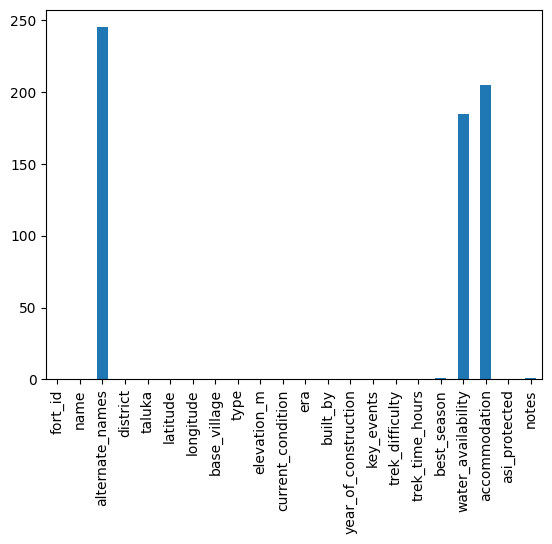

In [4]:
# Check for missing values
df.isna().sum().plot(kind='bar')

In [5]:
df.columns

Index(['fort_id', 'name', 'alternate_names', 'district', 'taluka', 'latitude',
       'longitude', 'base_village', 'type', 'elevation_m', 'current_condition',
       'era', 'built_by', 'year_of_construction', 'key_events',
       'trek_difficulty', 'trek_time_hours', 'best_season',
       'water_availability', 'accommodation', 'asi_protected', 'notes'],
      dtype='object')

In [6]:
# Number of unique fort types
len(df["type"].unique())

4

In [7]:
# Unique fort types names
df["type"].unique()

array(['Giri Durg (Hill Fort)', 'Bhuikot (Land Fort)',
       'Jal Durg (Sea Fort)', 'Van Durg (Forest Fort)'], dtype=object)

In [8]:
# Total number of forts
df["name"].count()

np.int64(346)

Text(0, 0.5, 'Number of Forts by Type')

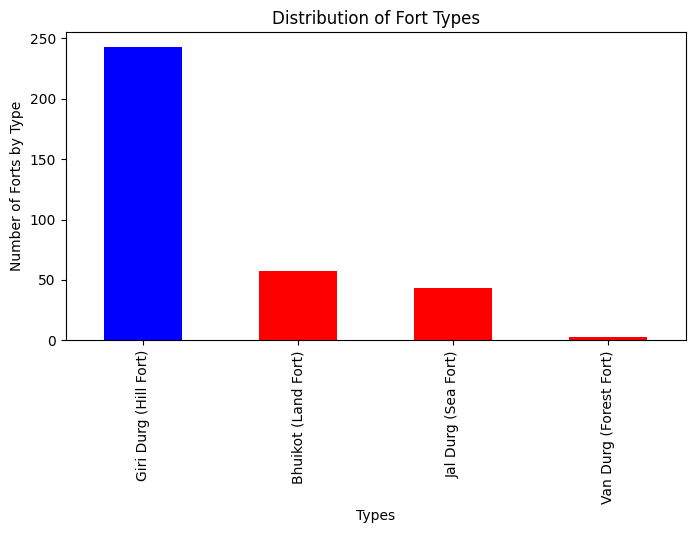

In [9]:
# Plot distribution of fort types
counts = df["type"].value_counts()
colors = ['blue' if x > 100 else 'red' for x in counts]

plt.figure(figsize=(8, 4))
counts.plot(kind='bar', color=colors)
plt.title("Distribution of Fort Types")
plt.xlabel("Types")
plt.ylabel("Number of Forts by Type")

In [10]:
# Removes 'c.' 
df["year_of_construction"] = (
    df["year_of_construction"]
    .str.replace(r"^c\.\s*", "", regex=True)
)

In [11]:
df

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,built_by,year_of_construction,key_events,trek_difficulty,trek_time_hours,best_season,water_availability,accommodation,asi_protected,notes
0,1,Aad Fort,NaN,Ratnagiri,Dapoli,17.7125,73.2391,Aad,Giri Durg (Hill Fort),250,...,Unknown,Unknown,Minor watchtower fort,Easy,1,Winter,NaN,NaN,FALSE,A small lesser-known fort covered in dense ve...
1,2,Achala Fort,NaN,Nashik,Satana,20.4578,74.0536,Pimpalgaon,Giri Durg (Hill Fort),1372,...,Shivaji Maharaj,17th Century,Part of Satmala hill range forts; Captured by ...,Medium,2,Winter,Seasonal,NaN,FALSE,"Twin fort to Ahivantgad, offers great views of..."
2,3,Achalpur Fort,Ellichpur Fort,Amravati,Achalpur,21.2612,77.5143,Achalpur,Bhuikot (Land Fort),358,...,Ahmad Shah Bahmani,1425,Capital of Berar Sultanate,Easy,0.5,Winter,NaN,NaN,TRUE,"Located inside the city, known for its massive..."
3,4,Adas Fort,NaN,Satara,Khatav,17.6534,74.6543,Adas,Giri Durg (Hill Fort),937,...,Unknown,17th Century,Minor watchtower fort,Easy,1,Post-Monsoon,NaN,NaN,FALSE,A small fort primarily used as a watch post.
4,5,Ahiwantgad,NaN,Nashik,Satana,20.4533,74.0494,Pimpalgaon,Giri Durg (Hill Fort),1385,...,Shivaji Maharaj,17th Century,Treaty of Purandar; Captured by British,Medium,2,Winter,Year-round in cisterns,Caves,FALSE,"Twin fort to Achala fort, features large caves..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Visapur Fort,NaN,Pune,Maval,18.7167,73.4833,Visapur,Giri Durg (Hill Fort),1084,...,Peshwas (rebuilt),1720,Twin fort to Lohagad; built to guard it,Easy,2,Monsoon; Winter,Seasonal,Caves,FALSE,"Known for its huge plateau, numerous water cis..."
342,343,Vishalgad,Khelna,Kolhapur,Shahuwadi,16.8833,73.7833,Gajapur,Giri Durg (Hill Fort),1130,...,Shilahara king Marsinh,1058,Where Shivaji Maharaj escaped to after fleeing...,Easy,1,Monsoon; Winter,Available,Dargah lodgings,FALSE,A large fort with significant historical monum...
343,344,Worli Fort,NaN,Mumbai City,Worli,19.0167,72.8167,Worli,Jal Durg (Sea Fort),8,...,British East India Company,1675,A small watchtower built to keep an eye on ene...,Easy,0.2,All Seasons,NaN,NaN,FALSE,"Located at the tip of Worli village, offering ..."
344,345,Yashawantgad (Nate),NaN,Ratnagiri,Rajapur,16.7212,73.3115,Nate,Jal Durg (Sea Fort),20,...,Shivaji Maharaj,17th Century,A coastal fort guarding the Nate creek,Easy,0.5,Winter,NaN,NaN,FALSE,A different fort from Yashwantgad/Redi Fort in...


In [12]:
# Create a new column 'raw_construction' to store 'year_of_construction' column data
df["raw_construction"] = df["year_of_construction"]

In [13]:
df["clean_construction"] = (
    df["year_of_construction"]
    .astype(str)
    .str.lower()
    .str.split(";")
    .str[0]
    .str.strip()
)

In [14]:
from helper_functions import extract_year, extract_centuries, extract_bce, extract_text

df["construction_year_bce"] = df["clean_construction"].apply(extract_bce)
df["construction_year_ce"] = df["clean_construction"].apply(extract_year)
df["construction_century_ce"], df["construction_century_bce"] = zip(*df.apply(
    lambda x: extract_centuries(
        x["clean_construction"],
        x["construction_year_ce"],
        x["construction_year_bce"]
    ),
    axis=1
))
df["construction_text"] = df.apply(
        lambda x: extract_text(
            x["clean_construction"], 
            x["construction_year_ce"], 
            x["construction_year_bce"]
        ),
        axis=1
)

In [15]:
# Fill missing values in 'construction_century_ce' with 'unknown'
df["construction_text"] = df["construction_text"].fillna("unknown")

In [16]:
from helper_functions import filter_text

df["construction_text"] = df["construction_text"].apply(filter_text)

In [17]:
# Fill missing values in 'construction_century_ce' with 'unknown'
df["construction_century_ce"] = df["construction_century_ce"].fillna("unknown")

In [18]:
# Fill missing values in 'construction_century_bce' with 'unknown'
df["construction_century_bce"] = df["construction_century_bce"].fillna("unknown")

In [19]:
df

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,accommodation,asi_protected,notes,raw_construction,clean_construction,construction_year_bce,construction_year_ce,construction_century_ce,construction_century_bce,construction_text
0,1,Aad Fort,NaN,Ratnagiri,Dapoli,17.7125,73.2391,Aad,Giri Durg (Hill Fort),250,...,NaN,FALSE,A small lesser-known fort covered in dense ve...,Unknown,unknown,NaN,NaN,unknown,unknown,unknown
1,2,Achala Fort,NaN,Nashik,Satana,20.4578,74.0536,Pimpalgaon,Giri Durg (Hill Fort),1372,...,NaN,FALSE,"Twin fort to Ahivantgad, offers great views of...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
2,3,Achalpur Fort,Ellichpur Fort,Amravati,Achalpur,21.2612,77.5143,Achalpur,Bhuikot (Land Fort),358,...,NaN,TRUE,"Located inside the city, known for its massive...",1425,1425,NaN,1425.0,15th Century,unknown,unknown
3,4,Adas Fort,NaN,Satara,Khatav,17.6534,74.6543,Adas,Giri Durg (Hill Fort),937,...,NaN,FALSE,A small fort primarily used as a watch post.,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
4,5,Ahiwantgad,NaN,Nashik,Satana,20.4533,74.0494,Pimpalgaon,Giri Durg (Hill Fort),1385,...,Caves,FALSE,"Twin fort to Achala fort, features large caves...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Visapur Fort,NaN,Pune,Maval,18.7167,73.4833,Visapur,Giri Durg (Hill Fort),1084,...,Caves,FALSE,"Known for its huge plateau, numerous water cis...",1720,1720,NaN,1720.0,18th Century,unknown,unknown
342,343,Vishalgad,Khelna,Kolhapur,Shahuwadi,16.8833,73.7833,Gajapur,Giri Durg (Hill Fort),1130,...,Dargah lodgings,FALSE,A large fort with significant historical monum...,1058,1058,NaN,1058.0,11th Century,unknown,unknown
343,344,Worli Fort,NaN,Mumbai City,Worli,19.0167,72.8167,Worli,Jal Durg (Sea Fort),8,...,NaN,FALSE,"Located at the tip of Worli village, offering ...",1675,1675,NaN,1675.0,17th Century,unknown,unknown
344,345,Yashawantgad (Nate),NaN,Ratnagiri,Rajapur,16.7212,73.3115,Nate,Jal Durg (Sea Fort),20,...,NaN,FALSE,A different fort from Yashwantgad/Redi Fort in...,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown


In [20]:
df.dtypes

fort_id                       int64
name                         object
alternate_names              object
district                     object
taluka                       object
latitude                    float64
longitude                   float64
base_village                 object
type                         object
elevation_m                   int64
current_condition            object
era                          object
built_by                     object
year_of_construction         object
key_events                   object
trek_difficulty              object
trek_time_hours              object
best_season                  object
water_availability           object
accommodation                object
asi_protected                object
notes                        object
raw_construction             object
clean_construction           object
construction_year_bce       float64
construction_year_ce        float64
construction_century_ce      object
construction_century_bce    

Text(0.5, 1.0, 'Missing Values in the Dataset')

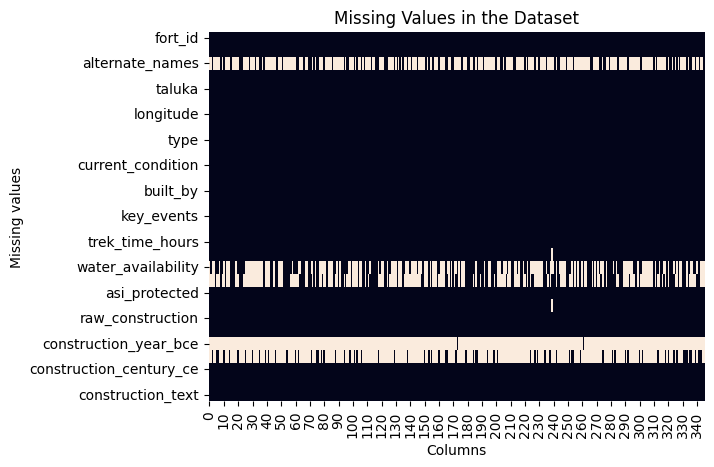

In [21]:
ax = plt.axes()

sns.heatmap(df.isna().transpose(), ax=ax, cbar=False)
plt.xlabel('Columns')
plt.ylabel('Missing values')
plt.title('Missing Values in the Dataset')

In [22]:
# Move a value from one column to the next column in the same row
row = 239
col = 'asi_protected'

idx = df.columns.get_loc(col)

if idx < len(df.columns) - 1:
    next_col = df.columns[idx + 1]

    if pd.isna(df.loc[row, next_col]):
        df.loc[row, next_col] = df.loc[row, col]
        df.loc[row, col] = None

In [23]:
# Move a value from one column to the next column in the same row
row = 239
col = 'accommodation'

idx = df.columns.get_loc(col)

if idx < len(df.columns) - 1:
    next_col = df.columns[idx + 1]

    if pd.isna(df.loc[row, next_col]):
        df.loc[row, next_col] = df.loc[row, col]
        df.loc[row, col] = None

In [24]:
df

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,accommodation,asi_protected,notes,raw_construction,clean_construction,construction_year_bce,construction_year_ce,construction_century_ce,construction_century_bce,construction_text
0,1,Aad Fort,NaN,Ratnagiri,Dapoli,17.7125,73.2391,Aad,Giri Durg (Hill Fort),250,...,NaN,FALSE,A small lesser-known fort covered in dense ve...,Unknown,unknown,NaN,NaN,unknown,unknown,unknown
1,2,Achala Fort,NaN,Nashik,Satana,20.4578,74.0536,Pimpalgaon,Giri Durg (Hill Fort),1372,...,NaN,FALSE,"Twin fort to Ahivantgad, offers great views of...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
2,3,Achalpur Fort,Ellichpur Fort,Amravati,Achalpur,21.2612,77.5143,Achalpur,Bhuikot (Land Fort),358,...,NaN,TRUE,"Located inside the city, known for its massive...",1425,1425,NaN,1425.0,15th Century,unknown,unknown
3,4,Adas Fort,NaN,Satara,Khatav,17.6534,74.6543,Adas,Giri Durg (Hill Fort),937,...,NaN,FALSE,A small fort primarily used as a watch post.,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
4,5,Ahiwantgad,NaN,Nashik,Satana,20.4533,74.0494,Pimpalgaon,Giri Durg (Hill Fort),1385,...,Caves,FALSE,"Twin fort to Achala fort, features large caves...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Visapur Fort,NaN,Pune,Maval,18.7167,73.4833,Visapur,Giri Durg (Hill Fort),1084,...,Caves,FALSE,"Known for its huge plateau, numerous water cis...",1720,1720,NaN,1720.0,18th Century,unknown,unknown
342,343,Vishalgad,Khelna,Kolhapur,Shahuwadi,16.8833,73.7833,Gajapur,Giri Durg (Hill Fort),1130,...,Dargah lodgings,FALSE,A large fort with significant historical monum...,1058,1058,NaN,1058.0,11th Century,unknown,unknown
343,344,Worli Fort,NaN,Mumbai City,Worli,19.0167,72.8167,Worli,Jal Durg (Sea Fort),8,...,NaN,FALSE,"Located at the tip of Worli village, offering ...",1675,1675,NaN,1675.0,17th Century,unknown,unknown
344,345,Yashawantgad (Nate),NaN,Ratnagiri,Rajapur,16.7212,73.3115,Nate,Jal Durg (Sea Fort),20,...,NaN,FALSE,A different fort from Yashwantgad/Redi Fort in...,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown


In [25]:
# Check for missing values
df.isna().sum()

fort_id                       0
name                          0
alternate_names             245
district                      0
taluka                        0
latitude                      0
longitude                     0
base_village                  0
type                          0
elevation_m                   0
current_condition             0
era                           0
built_by                      0
year_of_construction          0
key_events                    0
trek_difficulty               0
trek_time_hours               0
best_season                   1
water_availability          185
accommodation               206
asi_protected                 0
notes                         0
raw_construction              0
clean_construction            0
construction_year_bce       344
construction_year_ce        269
construction_century_ce       0
construction_century_bce      0
construction_text             0
dtype: int64

In [26]:
# Check proportion of missing values in 'alternate_names'
df['alternate_names'].isna().mean()

np.float64(0.708092485549133)

In [27]:
# Fill missing values in 'alternate_names' with '[NO_ALT_NAME]'
df['alternate_names'] = df['alternate_names'].fillna('[NO_ALT_NAME]')

In [28]:
df['water_availability'].value_counts(dropna=False)

water_availability
NaN                                         185
Seasonal                                     76
Year-round                                   31
Available                                    15
Year-round in cisterns                       13
Not applicable                               10
Seasonal in cisterns                          3
Bottled water sold                            2
Available at Rajmachi                         2
None on fort                                  2
Well on fort                                  2
Year-round well                               1
Sweet water well                              1
Potable water well                            1
Available seasonally; Bottled water sold      1
Monsoon; Winter                               1
Name: count, dtype: int64

In [29]:
# Fill missing values in 'water_availability' with 'Unknown'
df['water_availability'] = df['water_availability'].fillna('Unknown')

In [30]:
df

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,accommodation,asi_protected,notes,raw_construction,clean_construction,construction_year_bce,construction_year_ce,construction_century_ce,construction_century_bce,construction_text
0,1,Aad Fort,[NO_ALT_NAME],Ratnagiri,Dapoli,17.7125,73.2391,Aad,Giri Durg (Hill Fort),250,...,NaN,FALSE,A small lesser-known fort covered in dense ve...,Unknown,unknown,NaN,NaN,unknown,unknown,unknown
1,2,Achala Fort,[NO_ALT_NAME],Nashik,Satana,20.4578,74.0536,Pimpalgaon,Giri Durg (Hill Fort),1372,...,NaN,FALSE,"Twin fort to Ahivantgad, offers great views of...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
2,3,Achalpur Fort,Ellichpur Fort,Amravati,Achalpur,21.2612,77.5143,Achalpur,Bhuikot (Land Fort),358,...,NaN,TRUE,"Located inside the city, known for its massive...",1425,1425,NaN,1425.0,15th Century,unknown,unknown
3,4,Adas Fort,[NO_ALT_NAME],Satara,Khatav,17.6534,74.6543,Adas,Giri Durg (Hill Fort),937,...,NaN,FALSE,A small fort primarily used as a watch post.,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
4,5,Ahiwantgad,[NO_ALT_NAME],Nashik,Satana,20.4533,74.0494,Pimpalgaon,Giri Durg (Hill Fort),1385,...,Caves,FALSE,"Twin fort to Achala fort, features large caves...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Visapur Fort,[NO_ALT_NAME],Pune,Maval,18.7167,73.4833,Visapur,Giri Durg (Hill Fort),1084,...,Caves,FALSE,"Known for its huge plateau, numerous water cis...",1720,1720,NaN,1720.0,18th Century,unknown,unknown
342,343,Vishalgad,Khelna,Kolhapur,Shahuwadi,16.8833,73.7833,Gajapur,Giri Durg (Hill Fort),1130,...,Dargah lodgings,FALSE,A large fort with significant historical monum...,1058,1058,NaN,1058.0,11th Century,unknown,unknown
343,344,Worli Fort,[NO_ALT_NAME],Mumbai City,Worli,19.0167,72.8167,Worli,Jal Durg (Sea Fort),8,...,NaN,FALSE,"Located at the tip of Worli village, offering ...",1675,1675,NaN,1675.0,17th Century,unknown,unknown
344,345,Yashawantgad (Nate),[NO_ALT_NAME],Ratnagiri,Rajapur,16.7212,73.3115,Nate,Jal Durg (Sea Fort),20,...,NaN,FALSE,A different fort from Yashwantgad/Redi Fort in...,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown


In [31]:
# Check for missing values
df.isna().sum()

fort_id                       0
name                          0
alternate_names               0
district                      0
taluka                        0
latitude                      0
longitude                     0
base_village                  0
type                          0
elevation_m                   0
current_condition             0
era                           0
built_by                      0
year_of_construction          0
key_events                    0
trek_difficulty               0
trek_time_hours               0
best_season                   1
water_availability            0
accommodation               206
asi_protected                 0
notes                         0
raw_construction              0
clean_construction            0
construction_year_bce       344
construction_year_ce        269
construction_century_ce       0
construction_century_bce      0
construction_text             0
dtype: int64

In [32]:
df.dtypes

fort_id                       int64
name                         object
alternate_names              object
district                     object
taluka                       object
latitude                    float64
longitude                   float64
base_village                 object
type                         object
elevation_m                   int64
current_condition            object
era                          object
built_by                     object
year_of_construction         object
key_events                   object
trek_difficulty              object
trek_time_hours              object
best_season                  object
water_availability           object
accommodation                object
asi_protected                object
notes                        object
raw_construction             object
clean_construction           object
construction_year_bce       float64
construction_year_ce        float64
construction_century_ce      object
construction_century_bce    

In [33]:
# Check for missing values in 'best_season' column
df[df["best_season"].isna()]

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,accommodation,asi_protected,notes,raw_construction,clean_construction,construction_year_bce,construction_year_ce,construction_century_ce,construction_century_bce,construction_text
239,240,Parvatgad (Nashik),[NO_ALT_NAME],Nashik,Dindori,20.2512,73.8115,Parvatwadi,Giri Durg (Hill Fort),1050,...,None,FALSE,Lesser-known fort in the Dindori range.,Unknown,unknown,NaN,NaN,unknown,unknown,unknown


In [34]:
# Add value to 'best_season' column for the row with index 239
df.loc[239, "best_season"] = "Monsoon; Winter"

In [35]:
df.loc[315, "key_events"]

'Twin fort to Ghosalgad'

In [36]:
df.loc[315, "trek_difficulty"]

' guarding the Mandad river'

In [37]:
print(df.loc[315, ["key_events", "trek_difficulty"]])

key_events             Twin fort to Ghosalgad
trek_difficulty     guarding the Mandad river
Name: 315, dtype: object


In [38]:
# Add 'trek_difficulty' value to 'key_events' for the row with index 315
df.loc[315, "key_events"] = (
    df.loc[315, "key_events"] +
    df.loc[315, "trek_difficulty"]
)

In [39]:
print(df.loc[315, ["trek_time_hours", "trek_difficulty"]])

trek_time_hours                          Easy
trek_difficulty     guarding the Mandad river
Name: 315, dtype: object


In [40]:
# Add 'trek_time_hours' value to 'trek_difficulty' for the row with index 315
df.loc[315, "trek_difficulty"] = df.loc[315, "trek_time_hours"]

In [41]:
df.loc[315, "trek_time_hours"] = df.loc[315, "best_season"]

In [42]:
df.loc[315, "best_season"] = df.loc[315, "water_availability"]

In [43]:
df.loc[315, "water_availability"] = df.loc[315, "accommodation"]

In [44]:
# Add 'asi_protected' value to 'accommodation' for the row with index 315
df.loc[315, "accommodation"] = df.loc[315, "asi_protected"]

In [45]:
df.loc[315, "asi_protected"] = "TRUE"

In [46]:
# Remove patterns like 'Note:' at start of the sentences from 'notes' column
df["notes"] = df["notes"].str.replace(
    r"^Note:\s*",
    "",
    regex=True
)

In [47]:
# Remove patterns like '(ID 1234)' between the sentences from 'notes' column
df["notes"] = df["notes"].str.replace(
    r"\(ID\s*\d+\)",
    "",
    regex=True
)

In [51]:
df.isna().sum()

fort_id                       0
name                          0
alternate_names               0
district                      0
taluka                        0
latitude                      0
longitude                     0
base_village                  0
type                          0
elevation_m                   0
current_condition             0
era                           0
built_by                      0
year_of_construction          0
key_events                    0
trek_difficulty               0
trek_time_hours               0
best_season                   0
water_availability            0
accommodation                 0
asi_protected                 0
notes                         0
raw_construction              0
clean_construction            0
construction_year_bce       344
construction_year_ce        269
construction_century_ce       0
construction_century_bce      0
construction_text             0
dtype: int64

In [49]:
df['accommodation'] = df['accommodation'].fillna('Unknown')

In [53]:
# Fix typo in 'current_condition' column
df['current_condition'] = df['current_condition'].replace('Partially Ruinen', 'Partially Ruined')

In [ ]:
df['best_season'] = df['best_season'].replace('Winter; Post-Monsoon', 'Post-Monsoon; Winter')

In [ ]:
df.loc[335, "accommodation"] = "Caves"

In [59]:
df.loc[335, "asi_protected"] = "FALSE"

In [61]:
# Save cleaned dataset to a new CSV file
df.to_csv('data_cleaned.csv', index=False)

In [60]:
df

,fort_id,name,alternate_names,district,taluka,latitude,longitude,base_village,type,elevation_m,...,accommodation,asi_protected,notes,raw_construction,clean_construction,construction_year_bce,construction_year_ce,construction_century_ce,construction_century_bce,construction_text
0,1,Aad Fort,[NO_ALT_NAME],Ratnagiri,Dapoli,17.7125,73.2391,Aad,Giri Durg (Hill Fort),250,...,Unknown,FALSE,A small lesser-known fort covered in dense ve...,Unknown,unknown,NaN,NaN,unknown,unknown,unknown
1,2,Achala Fort,[NO_ALT_NAME],Nashik,Satana,20.4578,74.0536,Pimpalgaon,Giri Durg (Hill Fort),1372,...,Unknown,FALSE,"Twin fort to Ahivantgad, offers great views of...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
2,3,Achalpur Fort,Ellichpur Fort,Amravati,Achalpur,21.2612,77.5143,Achalpur,Bhuikot (Land Fort),358,...,Unknown,TRUE,"Located inside the city, known for its massive...",1425,1425,NaN,1425.0,15th Century,unknown,unknown
3,4,Adas Fort,[NO_ALT_NAME],Satara,Khatav,17.6534,74.6543,Adas,Giri Durg (Hill Fort),937,...,Unknown,FALSE,A small fort primarily used as a watch post.,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
4,5,Ahiwantgad,[NO_ALT_NAME],Nashik,Satana,20.4533,74.0494,Pimpalgaon,Giri Durg (Hill Fort),1385,...,Caves,FALSE,"Twin fort to Achala fort, features large caves...",17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Visapur Fort,[NO_ALT_NAME],Pune,Maval,18.7167,73.4833,Visapur,Giri Durg (Hill Fort),1084,...,Caves,FALSE,"Known for its huge plateau, numerous water cis...",1720,1720,NaN,1720.0,18th Century,unknown,unknown
342,343,Vishalgad,Khelna,Kolhapur,Shahuwadi,16.8833,73.7833,Gajapur,Giri Durg (Hill Fort),1130,...,Dargah lodgings,FALSE,A large fort with significant historical monum...,1058,1058,NaN,1058.0,11th Century,unknown,unknown
343,344,Worli Fort,[NO_ALT_NAME],Mumbai City,Worli,19.0167,72.8167,Worli,Jal Durg (Sea Fort),8,...,Unknown,FALSE,"Located at the tip of Worli village, offering ...",1675,1675,NaN,1675.0,17th Century,unknown,unknown
344,345,Yashawantgad (Nate),[NO_ALT_NAME],Ratnagiri,Rajapur,16.7212,73.3115,Nate,Jal Durg (Sea Fort),20,...,Unknown,FALSE,A different fort from Yashwantgad/Redi Fort in...,17th Century,17th century,NaN,NaN,17th Century,unknown,unknown
